# Visualising learned representations

This notebook shows how to visualise the token representations of a trained model. This can shed light on the abstract structure it has learned from the training data, e.g. in the example below a model trained on a very simplified spatial task learns a 2D map.

This notebook uses two models trained in Spens & Burgess (2026) for relational inference, which are loaded from Google Drive. These models are trained on walks on graphs, which represent spatial relationships (in 3x3 gridworlds) for the spatial model, and family relations for the family tree model. 

Further background on the models / task: As in Whittington et al. (2020), this work models the spatial task of predicting the next location in a trajectory as the prediction of the next node in a graph. We create a large set of graphs, each one an n-by-n grid of nodes representing a simple spatial environment. Nodes are labelled with random letters to represent arbitrary associations at a particular location. Each directed edge, i.e. each possible transition in the graph, is of the type north, south, east, or west. Random walks in the set of graphs are used to train the model; these could represent sequences stored in an initial bank of memories. The generative model is trained from scratch on the replayed sequences (converted to strings of the form ‘node1 E node2 W node3 …’) with the mechanism of causal language modelling. The family tree case is similar but the edges represent relations like 'sibling of' or 'child of'.

## Load the model:

In [1]:
from llm_psychology.viz import locate_or_download_final_rel_inf_model

model_root = locate_or_download_final_rel_inf_model()
print("Using relational model root:", model_root.name)

Using relational model root: final_rel_inf


## Configure the PCA code

For a faster test, temporarily set `REL_PCA_N_SAMPLES` to a smaller value before running the notebook.

In [2]:
import os
from pathlib import Path

from llm_psychology.viz import (
    RelationalPCAConfig,
    collect_family_points_by_layer,
    collect_spatial_points_by_layer,
    load_causal_lm_with_tokenizer,
    make_family_examples,
    make_spatial_examples,
    plot_family_layer_pca,
    plot_spatial_all_layers_pca,
    plot_spatial_layer_pca,
)

out_dir = Path("../outputs/tutorial_visualisation")
out_dir.mkdir(parents=True, exist_ok=True)

config = RelationalPCAConfig(
    n_samples=int(os.environ.get("REL_PCA_N_SAMPLES", 1000)),
    walk_length=50,
    layer_index=12,
    batch_size=12,
    seed=321,
    use_flanking=True,
    second_half_only=False,
    l2_normalize=True,
)
config

RelationalPCAConfig(n_samples=1000, walk_length=50, layer_index=12, layers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], batch_size=12, seed=321, use_flanking=True, second_half_only=False, l2_normalize=True)

## Spatial model: PCA across all layers

The spatial task is useful for hidden state visualisation because each two-letter entity has a known grid position. This section samples walks, extracts entity representations from every model layer, and fits a separate PCA for each layer.

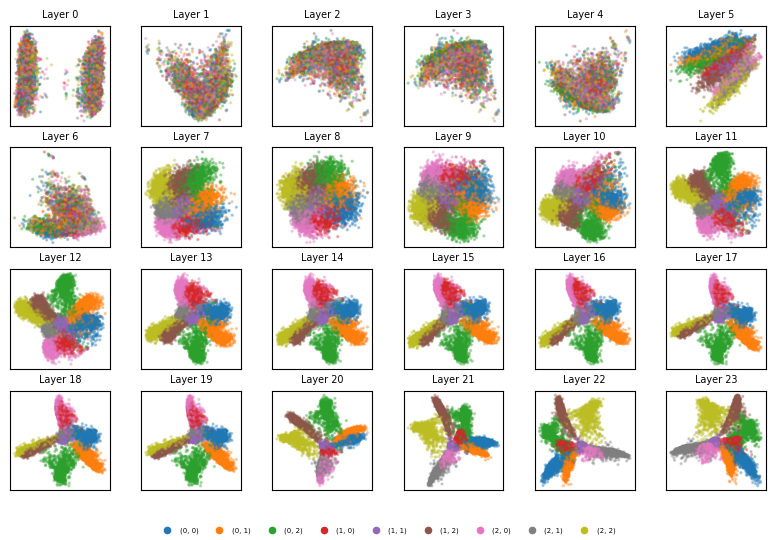

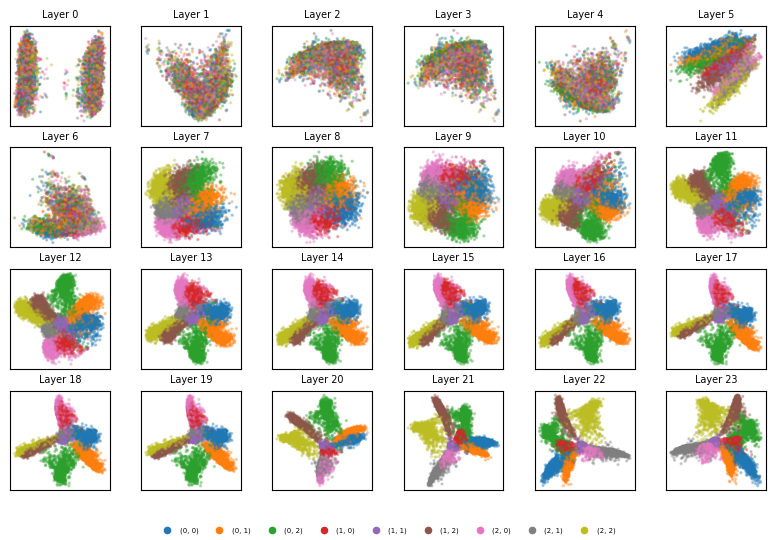

In [3]:
spatial_examples = make_spatial_examples(
    config.n_samples,
    walk_length=config.walk_length,
    seed=config.seed,
)

spatial_model, spatial_tokenizer = load_causal_lm_with_tokenizer(model_root / "outputs_graph")
spatial_points_by_layer = collect_spatial_points_by_layer(
    spatial_model,
    spatial_tokenizer,
    spatial_examples,
    layers=config.layers,
    config=config,
)

fig = plot_spatial_all_layers_pca(
    spatial_points_by_layer,
    l2_normalize=config.l2_normalize,
)
fig.savefig(out_dir / f"spatial_all_layers_pca_n{config.n_samples}.png", dpi=220, bbox_inches="tight")
fig

## Spatial model: layer 12 PCA

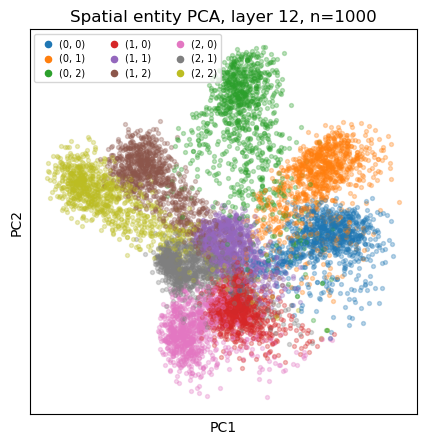

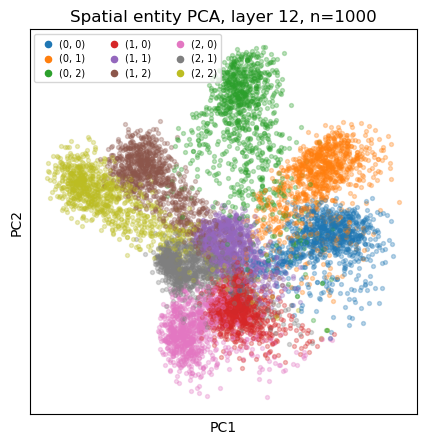

In [4]:
fig = plot_spatial_layer_pca(
    spatial_points_by_layer[config.layer_index],
    title=f"Spatial entity PCA, layer {config.layer_index}, n={config.n_samples}",
    l2_normalize=config.l2_normalize,
)
fig.savefig(out_dir / f"spatial_layer{config.layer_index}_pca_n{config.n_samples}.png", dpi=200, bbox_inches="tight")
fig

## Family tree model: layer 12 PCA

The graphs in the family tree task involve three 'generations'.

Let's check whether hidden representations separate people by generation in the family tree task. This cell samples instances of the three generation family structure and colours entities as grandparents, parents, or children.

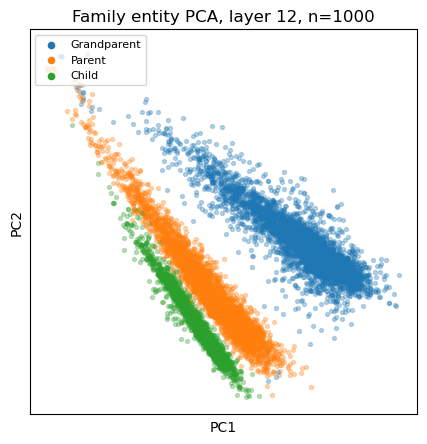

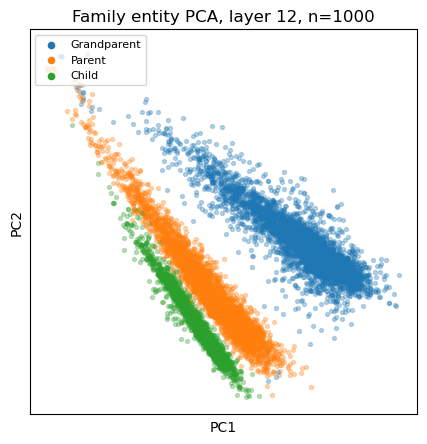

In [5]:
family_examples = make_family_examples(
    config.n_samples,
    walk_length=config.walk_length,
    seed=config.seed,
)

family_model, family_tokenizer = load_causal_lm_with_tokenizer(model_root / "outputs_tree")
family_points_by_layer = collect_family_points_by_layer(
    family_model,
    family_tokenizer,
    family_examples,
    layers=[config.layer_index],
    config=config,
)

fig = plot_family_layer_pca(
    family_points_by_layer[config.layer_index],
    title=f"Family entity PCA, layer {config.layer_index}, n={config.n_samples}",
    l2_normalize=config.l2_normalize,
)
fig.savefig(out_dir / f"family_layer{config.layer_index}_pca_n{config.n_samples}.png", dpi=200, bbox_inches="tight")
fig